# NYC Subway Complaints EDA

This is an exploratory data analysis of historic NYPD complaint data where we'll be looking at crimes that were reported on the subway.

The [NYPD Complaint Data Historic](https://data.cityofnewyork.us/Public-Safety/NYPD-Complaint-Data-Historic/qgea-i56i/) dataset is free to download from the [NYC Open Data](https://opendata.cityofnewyork.us/) website.

This dataset includes all valid felony, misdemeanor, and violation crimes reported to the New York City Police Department (NYPD) from 2006 to the end of last year (2025). For the purposes of this analysis, we will look at crimes between 2018 - 2025.

## Config

### Install Packages

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import requests

### Configure Pandas

In [71]:
# set Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Configure Plots

In [72]:
sns.set_style("whitegrid")  # whitegrid
# sns.set_theme(context='notebook', style='whitegrid', palette='tab10', font=font_name, rc={"figure.dpi": 96})
plt.rcParams['figure.frameon'] = True
plt.rcParams['figure.dpi'] = 96
plt.rcParams['figure.facecolor'] ='#fafafa'
colors = plt.color_sequences['tab20c']

### Install Poppins Font

In [73]:
POPPINS_LIGHT_FONT_GITHUB_URL = "https://github.com/google/fonts/blob/main/ofl/poppins/Poppins-Light.ttf?raw=true"
POPPINS_REGULAR_FONT_GITHUB_URL = "https://github.com/google/fonts/blob/main/ofl/poppins/Poppins-Regular.ttf?raw=true"
POPPINS_BOLD_FONT_GITHUB_URL = "https://github.com/google/fonts/blob/main/ofl/poppins/Poppins-Bold.ttf?raw=true"

In [74]:
POPPINS_LIGHT_FONT_PATH = "../data/Poppins-Light.ttf"
POPPINS_REGULAR_FONT_PATH = "../data/Poppins-Regular.ttf"
POPPINS_BOLD_FONT_PATH = "../data/Poppins-Bold.ttf.ttf"

In [75]:
for font_url, font_path in [
    (POPPINS_LIGHT_FONT_GITHUB_URL, POPPINS_LIGHT_FONT_PATH),
    (POPPINS_REGULAR_FONT_GITHUB_URL, POPPINS_REGULAR_FONT_PATH),
    (POPPINS_BOLD_FONT_GITHUB_URL, POPPINS_BOLD_FONT_PATH)
]:

    if not os.path.exists(font_path):
        print(f"Downloading Inter Variable font from: {font_url}")
        os.makedirs("../data", exist_ok=True)

        try:
            # request the font from url
            with requests.get(font_url, stream=True) as response:
                # check if the request was successful
                response.raise_for_status()
                # write the data to the file
                with open(font_path, 'wb') as f:
                    f.write(response.content)
                print("Inter font downloaded successfully!")
        except requests.exceptions.RequestException as e:
            print(f"An error occurred requesting the font: {e}")

    else:
        print(f"Found a local copy of {font_path.split("/")[-1]} font, skipping download.")

Found a local copy of Poppins-Light.ttf font, skipping download.
Found a local copy of Poppins-Regular.ttf font, skipping download.
Found a local copy of Poppins-Bold.ttf.ttf font, skipping download.


In [76]:
loaded_fonts = []
for font_path in [POPPINS_LIGHT_FONT_PATH, POPPINS_REGULAR_FONT_PATH, POPPINS_BOLD_FONT_PATH]:
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_prop = fm.FontProperties(fname=font_path)
        font_name = font_prop.get_name()
        loaded_fonts.append(font_name)

if loaded_fonts:
    plt.rcParams['font.family'] = ["Poppins"]
    plt.rcParams['font.sans-serif'] = loaded_fonts

    print("Font loaded successfully.")

Font loaded successfully.


## Load data



In [7]:
OPEN_DATA_CSV_PATH = "../data/NYPD_Complaint_Data_Historic_20260505.csv"

In [8]:
# check if the 'data' directory exists, if not create it
if not os.path.exists('../data'):
    os.makedirs('../data', exist_ok=True)
# check if the 'data/complaints.csv' file exists, if not prompt the user to download it
if not os.path.exists(OPEN_DATA_CSV_PATH):
    print("Please download the complaints.csv file from the NYC Open Data portal and place it in the 'data' directory.")
else:
    print(f"{OPEN_DATA_CSV_PATH.split("/")[-1]} file found.")

NYPD_Complaint_Data_Historic_20260505.csv file found.


In [9]:
df = pd.read_csv(OPEN_DATA_CSV_PATH, parse_dates=["CMPLNT_FR_DT"], low_memory=False)

In [10]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 4013797 entries, 0 to 4013796
Data columns (total 35 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   CMPLNT_NUM         4013797 non-null  str           
 1   CMPLNT_FR_DT       4013797 non-null  datetime64[us]
 2   CMPLNT_FR_TM       4013797 non-null  str           
 3   CMPLNT_TO_DT       3684322 non-null  str           
 4   CMPLNT_TO_TM       4013797 non-null  str           
 5   ADDR_PCT_CD        4013700 non-null  float64       
 6   RPT_DT             4013797 non-null  str           
 7   KY_CD              4013797 non-null  int64         
 8   OFNS_DESC          4013797 non-null  str           
 9   PD_CD              4010804 non-null  float64       
 10  PD_DESC            4013797 non-null  str           
 11  CRM_ATPT_CPTD_CD   4013797 non-null  str           
 12  LAW_CAT_CD         4013797 non-null  str           
 13  BORO_NM            4013797 non-null  s

### Duplicates

In [11]:
# confirm that the date range is from 2018 - 2025
print(f"Date range: {df['CMPLNT_FR_DT'].min()} to {df['CMPLNT_FR_DT'].max()}")

Date range: 2018-01-01 00:00:00 to 2025-12-31 00:00:00


In [12]:
# check for duplicate rows by CMPLNT_NUM and drop duplicates if found
duplicate_count = df.duplicated(subset=['CMPLNT_NUM']).sum()
print(f"Number of duplicate rows based on CMPLNT_NUM: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates(subset=['CMPLNT_NUM'])
    print(f"Dropped {duplicate_count} duplicate rows based on CMPLNT_NUM.")

Number of duplicate rows based on CMPLNT_NUM: 2
Dropped 2 duplicate rows based on CMPLNT_NUM.


### Preview the data

In [13]:
df.head()

,CMPLNT_NUM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,ADDR_PCT_CD,RPT_DT,KY_CD,OFNS_DESC,PD_CD,PD_DESC,CRM_ATPT_CPTD_CD,LAW_CAT_CD,BORO_NM,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,JURIS_DESC,JURISDICTION_CODE,PARKS_NM,HADEVELOPT,HOUSING_PSA,X_COORD_CD,Y_COORD_CD,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,TRANSIT_DISTRICT,Latitude,Longitude,Lat_Lon,PATROL_BORO,STATION_NAME,VIC_AGE_GROUP,VIC_RACE,VIC_SEX
0,318206301,2025-12-31,20:00:00,12/31/2025,20:40:00,50.0,12/31/2025,341,PETIT LARCENY,333.0,"LARCENY,PETIT FROM STORE-SHOPL",COMPLETED,MISDEMEANOR,BRONX,INSIDE,CHAIN STORE,N.Y. POLICE DEPT,0,(null),(null),(null),"1,012,824","271,127",UNKNOWN,BLACK,M,NaN,40.910818,-73.896621,"(40.910818, -73.896621)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,D
1,318196619,2025-12-30,19:00:00,12/30/2025,20:00:00,47.0,12/31/2025,126,MISCELLANEOUS PENAL LAW,198.0,CRIMINAL CONTEMPT 1,COMPLETED,FELONY,BRONX,(null),RESIDENCE-HOUSE,N.Y. POLICE DEPT,0,(null),(null),(null),"1,025,454","268,214",65+,AMERICAN INDIAN/ALASKAN NATIVE,M,NaN,40.902772,-73.850946,"(40.902772, -73.850946)",PATROL BORO BRONX,(null),<18,WHITE,M
2,318194616,2025-12-31,12:30:00,NaN,(null),47.0,12/31/2025,344,ASSAULT 3 & RELATED OFFENSES,113.0,"MENACING,UNCLASSIFIED",COMPLETED,MISDEMEANOR,BRONX,INSIDE,HOMELESS SHELTER,N.Y. POLICE DEPT,0,(null),(null),(null),"1,024,875","269,317",<18,WHITE HISPANIC,F,NaN,40.905803,-73.853032,"(40.905803, -73.853032)",PATROL BORO BRONX,(null),25-44,WHITE HISPANIC,M
3,318206286,2025-12-31,19:15:00,NaN,(null),47.0,12/31/2025,361,OFF. AGNST PUB ORD SENSBLTY &,639.0,AGGRAVATED HARASSMENT 2,COMPLETED,MISDEMEANOR,BRONX,INSIDE,RESIDENCE - APT. HOUSE,N.Y. POLICE DEPT,0,(null),(null),(null),"1,024,326","265,010",25-44,BLACK,M,NaN,40.893985,-73.855046,"(40.893985, -73.855046)",PATROL BORO BRONX,(null),45-64,BLACK,F
4,318179017,2025-12-31,00:52:00,12/31/2025,01:18:00,47.0,12/31/2025,344,ASSAULT 3 & RELATED OFFENSES,101.0,ASSAULT 3,COMPLETED,MISDEMEANOR,BRONX,INSIDE,RESIDENCE - APT. HOUSE,N.Y. POLICE DEPT,0,(null),(null),(null),"1,023,593","261,233",<18,BLACK,F,NaN,40.883621,-73.857720,"(40.883621, -73.85772)",PATROL BORO BRONX,(null),<18,BLACK,M


### Categorical data

In [95]:
# convert LAW_CAT_CD to ordered categorical type
law_cat_order = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
# convert values to title case
df['LAW_CAT_CD'] = df['LAW_CAT_CD'].str.title()
df['LAW_CAT_CD'] = pd.Categorical(df['LAW_CAT_CD'], categories=[x.title() for x in law_cat_order], ordered=True)

## Analysis

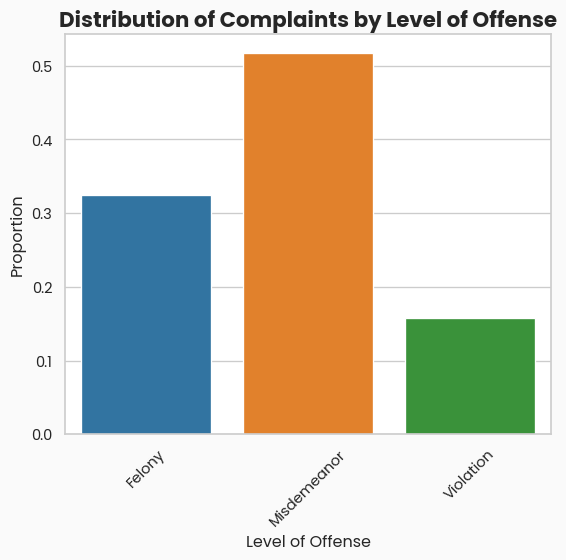

In [97]:
# Plot the distribution of LAW_CAT_CD
plt.figure(figsize=(6, 6))
ax = sns.countplot(data=df, x='LAW_CAT_CD', hue='LAW_CAT_CD', stat="proportion", width=0.8, dodge=False)
# Use large bolder font for title and axis labels
plt.title('Distribution of Complaints by Level of Offense', fontsize=16, fontweight="bold")
plt.xlabel('Level of Offense', fontsize=12, fontweight='regular')
plt.ylabel('Proportion', fontsize=12, fontweight='regular')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()